## **NDCI Analysis Workflow**

**Step 1: import libraries and packages**

In [1]:
import pystac_client
import rioxarray
import planetary_computer
from shapely.geometry import box
import geopandas as gpd
import matplotlib.pyplot as plt
import contextily as ctx
import odc.stac
import pandas as pd

**Step 2: define access to Microsoft Planetary Computer's Sentinel-2 STAC catalog and examine contents**

In [2]:
catalog = pystac_client.Client.open("https://planetarycomputer.microsoft.com/api/stac/v1", modifier=planetary_computer.sign_inplace)

catalog

<Client id=microsoft-pc>

**Step 3: define location and time period for analysis and access the corresponding information through the catalog**

In [3]:
start_date = "2022-06-01"
end_date = "2022-06-30"
bbox = (-122.60, 48.18, -122.30, 48.45)

search = catalog.search(collections=["sentinel-2-l2a"], bbox=bbox, datetime=f"{start_date}/{end_date}", query={"eo:cloud_cover": {"lt": 15}})
items = search.item_collection()
print(f"Total items found: {len(items)}")

item = items[0]
print(f"Item ID: {item.id}, Date: {item.datetime.strftime('%Y-%m-%d')}, Cloud cover: {item.properties['eo:cloud_cover']}%")
print("\nAvailable assets:")
for asset_key, asset in item.assets.items():
    print(f"- {asset_key}: {asset.title if hasattr(asset, 'title') else ''}")

Total items found: 2
Item ID: S2A_MSIL2A_20220626T185931_R013_T10UEU_20220627T095427, Date: 2022-06-26, Cloud cover: 0.035341%

Available assets:
- AOT: Aerosol optical thickness (AOT)
- B01: Band 1 - Coastal aerosol - 60m
- B02: Band 2 - Blue - 10m
- B03: Band 3 - Green - 10m
- B04: Band 4 - Red - 10m
- B05: Band 5 - Vegetation red edge 1 - 20m
- B06: Band 6 - Vegetation red edge 2 - 20m
- B07: Band 7 - Vegetation red edge 3 - 20m
- B08: Band 8 - NIR - 10m
- B09: Band 9 - Water vapor - 60m
- B11: Band 11 - SWIR (1.6) - 20m
- B12: Band 12 - SWIR (2.2) - 20m
- B8A: Band 8A - Vegetation red edge 4 - 20m
- SCL: Scene classfication map (SCL)
- WVP: Water vapour (WVP)
- visual: True color image
- preview: Thumbnail
- safe-manifest: SAFE manifest
- granule-metadata: Granule metadata
- inspire-metadata: INSPIRE metadata
- product-metadata: Product metadata
- datastrip-metadata: Datastrip metadata
- tilejson: TileJSON with default rendering
- rendered_preview: Rendered preview


In [4]:
zoom_bbox = (-122.5, 48.24, -122.35, 48.35)

zoom_gdf = gpd.GeoDataFrame(geometry=[box(*zoom_bbox)], crs="EPSG:4326")

**Step 5: load items into a xarray dataset**

In [5]:
states_gdf = gpd.read_file('http://eric.clst.org/assets/wiki/uploads/Stuff/gz_2010_us_040_00_5m.json')
wa_gdf = states_gdf[states_gdf['NAME'] == 'Washington']
wa_gdf_clipped = gpd.clip(wa_gdf, box(*zoom_bbox))

bbox = (-122.60, 48.18, -122.30, 48.45)
skagit_gdf = gpd.GeoDataFrame(geometry=[box(*bbox)], crs="EPSG:4326") # for visualization
all_items = list(catalog.search(collections=["sentinel-2-l2a"], bbox=bbox, datetime=f"{start_date}/{end_date}", query={"s2:mgrs_tile": {"eq": "10UEU"}}).item_collection()) + list(catalog.search(collections=["sentinel-2-l2a"], bbox=bbox, datetime=f"{start_date}/{end_date}", query={"s2:mgrs_tile": {"eq": "10TET"}}).item_collection())
print(f"Total items: {len(all_items)}")

signed_items = [planetary_computer.sign(item) for item in all_items]
bands = ["B02", "B03", "B04", "B05", "SCL"]
s2_ds = odc.stac.load(signed_items, bands=bands, resolution=0.001, chunks={}, groupby='solar_day', bbox=zoom_bbox, crs="EPSG:4326")
s2_ds_water = s2_ds.rio.clip(wa_gdf_clipped.geometry, wa_gdf_clipped.crs, drop=False, invert=True)
print(s2_ds)

Total items: 12
<xarray.Dataset> Size: 4MB
Dimensions:      (latitude: 110, longitude: 150, time: 12)
Coordinates:
  * latitude     (latitude) float64 880B 48.35 48.35 48.35 ... 48.24 48.24 48.24
  * longitude    (longitude) float64 1kB -122.5 -122.5 -122.5 ... -122.4 -122.4
    spatial_ref  int32 4B 4326
  * time         (time) datetime64[ns] 96B 2022-06-01T18:59:19.024000 ... 202...
Data variables:
    B02          (time, latitude, longitude) float32 792kB dask.array<chunksize=(1, 110, 150), meta=np.ndarray>
    B03          (time, latitude, longitude) float32 792kB dask.array<chunksize=(1, 110, 150), meta=np.ndarray>
    B04          (time, latitude, longitude) float32 792kB dask.array<chunksize=(1, 110, 150), meta=np.ndarray>
    B05          (time, latitude, longitude) float32 792kB dask.array<chunksize=(1, 110, 150), meta=np.ndarray>
    SCL          (time, latitude, longitude) float32 792kB dask.array<chunksize=(1, 110, 150), meta=np.ndarray>


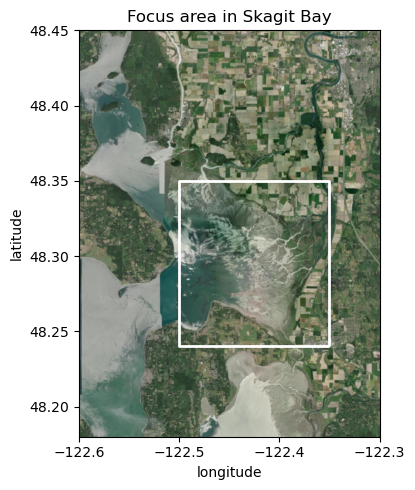

In [6]:
fig, ax = plt.subplots(figsize=(10,5))

bounds = skagit_gdf.total_bounds
ax.set_xlim(bounds[0], bounds[2])
ax.set_ylim(bounds[1], bounds[3])

ctx.add_basemap(ax, crs=skagit_gdf.crs, source=ctx.providers.Esri.WorldImagery, attribution=False)
ax.set_title("Focus area in Skagit Bay")
ax.set_xlabel('longitude')
ax.set_ylabel('latitude')
zoom_gdf.boundary.plot(ax=ax, color="white", linewidth=2)
ax.xaxis.set_major_locator(plt.MultipleLocator(0.1))

fig.tight_layout()

**Step 6: let's explore our dateset with an RGB composite timeseries and examine cloud cover issues**

In [7]:
# First define the RBG data array

rgb_da = s2_ds[["B04", "B03", "B02"]].to_array(dim='band').compute()
rgb_da

/opt/conda/lib/python3.11/site-packages/rasterio/warp.py:387: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dest = _reproject(


<xarray.DataArray (band: 3, time: 12, latitude: 110, longitude: 150)> Size: 2MB
array([[[[3436., 3433., 3427., ..., 3469., 3468., 3475.],
         [3436., 3440., 3436., ..., 3499., 3518., 3572.],
         [3440., 3441., 3443., ..., 3551., 3583., 3562.],
         ...,
         [4398., 4400., 4399., ..., 4180., 4187., 4173.],
         [4425., 4431., 4429., ..., 4178., 4151., 4164.],
         [4440., 4436., 4440., ..., 4158., 4132., 4115.]],

        [[1816., 1783., 1911., ..., 1630., 1660., 1450.],
         [1665., 1695., 1796., ..., 1789., 1820., 1906.],
         [1614., 1645., 1643., ..., 1990., 1899., 1705.],
         ...,
         [1210., 1271., 1305., ..., 3036., 2530., 2422.],
         [1290., 1538., 1576., ..., 2633., 2494., 3155.],
         [1235., 1237., 1402., ..., 2725., 2365., 3103.]],

        [[2271., 2335., 2443., ..., 2699., 2806., 2934.],
         [2448., 2429., 2410., ..., 2711., 2789., 2895.],
         [2416., 2479., 2475., ..., 2812., 2875., 2905.],
         ...,
...
         ...,
         [1187., 1241., 1322., ..., 2411., 2717., 2503.],
         [1266., 1464., 1494., ..., 2468., 2021., 2517.],
         [1198., 1218., 1304., ..., 2038., 3148., 1780.]],

        [[1536., 1539., 1528., ..., 1572., 1556., 1558.],
         [1482., 1550., 1560., ..., 1461., 1535., 2039.],
         [1468., 1508., 1585., ..., 1903., 2150., 2385.],
         ...,
         [1157., 1217., 1336., ..., 2489., 2747., 2518.],
         [1253., 1497., 1516., ..., 2471., 2038., 2508.],
         [1175., 1203., 1298., ..., 2094., 3296., 1779.]],

        [[4395., 4247., 3898., ..., 8970., 8986., 9093.],
         [4345., 3742., 3500., ..., 8845., 9135., 8861.],
         [4486., 3898., 3573., ..., 8050., 8388., 7611.],
         ...,
         [8033., 8137., 7958., ..., 7652., 7777., 7902.],
         [8043., 7714., 7727., ..., 7094., 7273., 7694.],
         [7721., 7456., 7317., ..., 7003., 7231., 7598.]]]], dtype=float32)
Coordinates:
  * latitude     (latitude) float64 880B 48.35 48.35 48.35 ... 48.24 48.24 48.24
  * longitude    (longitude) float64 1kB -122.5 -122.5 -122.5 ... -122.4 -122.4
    spatial_ref  int32 4B 4326
  * time         (time) datetime64[ns] 96B 2022-06-01T18:59:19.024000 ... 202...
  * band         (band) object 24B 'B04' 'B03' 'B02'

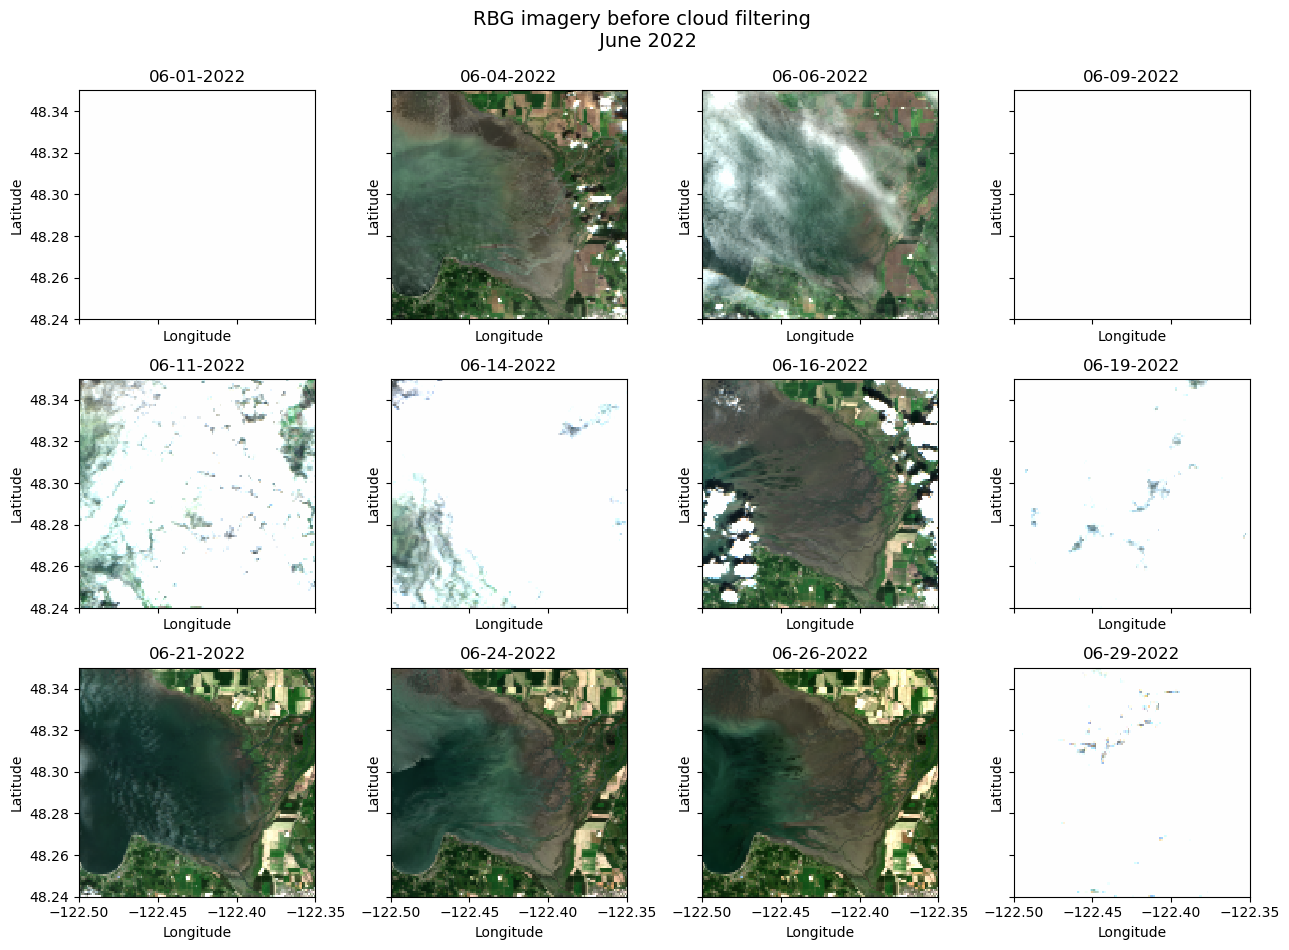

In [8]:
# Then plot all data available in June 2022
rgb_normalized = (rgb_da / 3000.0).clip(0, 1)

rgb = rgb_normalized.plot.imshow(col='time', col_wrap=4, robust=False)

for ax, t in zip(rgb.axes.flat, rgb_normalized.time.values):
    ax.set_title(pd.Timestamp(t).strftime("%m-%d-%Y"))
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")

plt.tight_layout()
plt.suptitle("RBG imagery before cloud filtering \n June 2022", y=1.05, fontsize=14);
plt.savefig("rbgbeforefiltering.png", dpi=300, bbox_inches='tight')

After inspected our plots, it is clear that we are running into some cloud cover issues. We will clean that up when we plot our NDCI.

In [9]:
cloud_scl = [8, 9, 10]
cloud_fraction = s2_ds_water["SCL"].isin(cloud_scl).mean(dim=["latitude", "longitude"]).compute()
print(f"Cloud fractions:\n{cloud_fraction.values}")

cloud_threshold = 0.30

clean_times = cloud_fraction.time.where(cloud_fraction < cloud_threshold, drop=True)

print(f"Timesteps before: {len(s2_ds_water.time.values)}")
print(f"Timesteps after filtering: {len(clean_times.values)}")

Cloud fractions:
[0.55151515 0.00066667 0.07872727 0.55151515 0.44612121 0.49381818
 0.048      0.54448485 0.         0.         0.         0.55151515]
Timesteps before: 12
Timesteps after filtering: 6


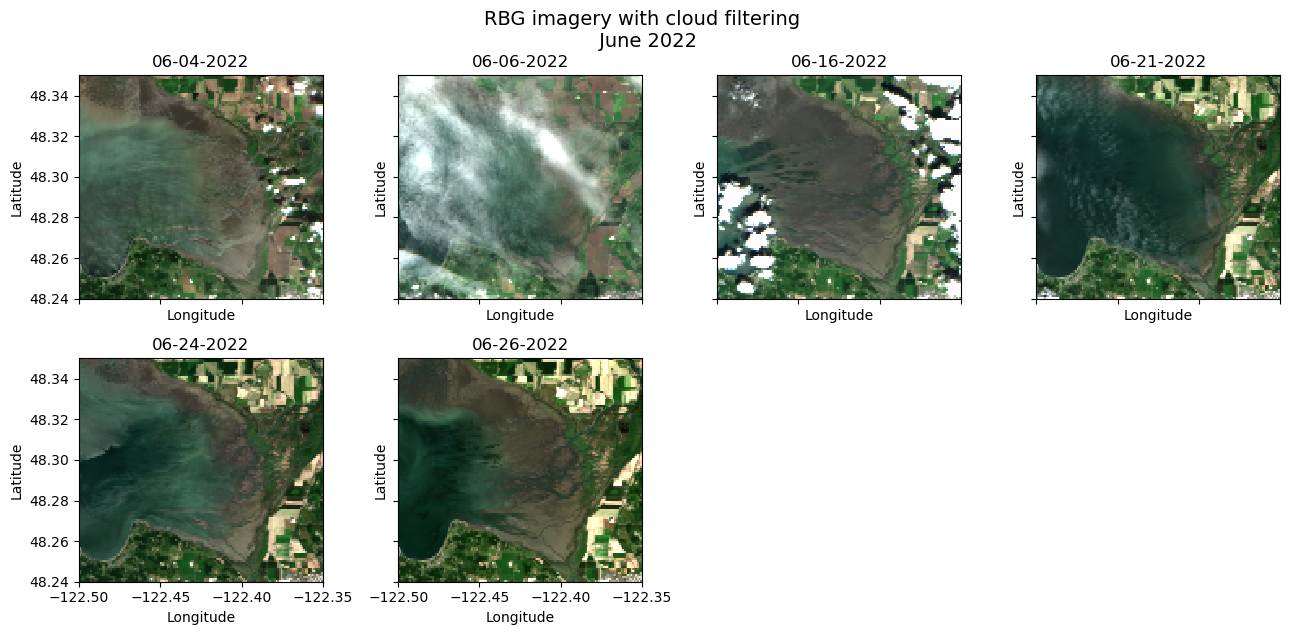

In [10]:
rgb_da = s2_ds[["B04", "B03", "B02"]].to_array(dim='band').sel(time=clean_times).compute()

rgb_normalized = (rgb_da / 3000.0).clip(0, 1)
rgb = rgb_normalized.plot.imshow(col='time', col_wrap=4, robust=False)
for ax, t in zip(rgb.axes.flat, rgb_normalized.time.values):
    ax.set_title(pd.Timestamp(t).strftime("%m-%d-%Y"))
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")

plt.tight_layout()
plt.suptitle("RBG imagery with cloud filtering \n June 2022", y=1.05, fontsize=14);

**Step 7: calculate and plot NDCI for the focus area**

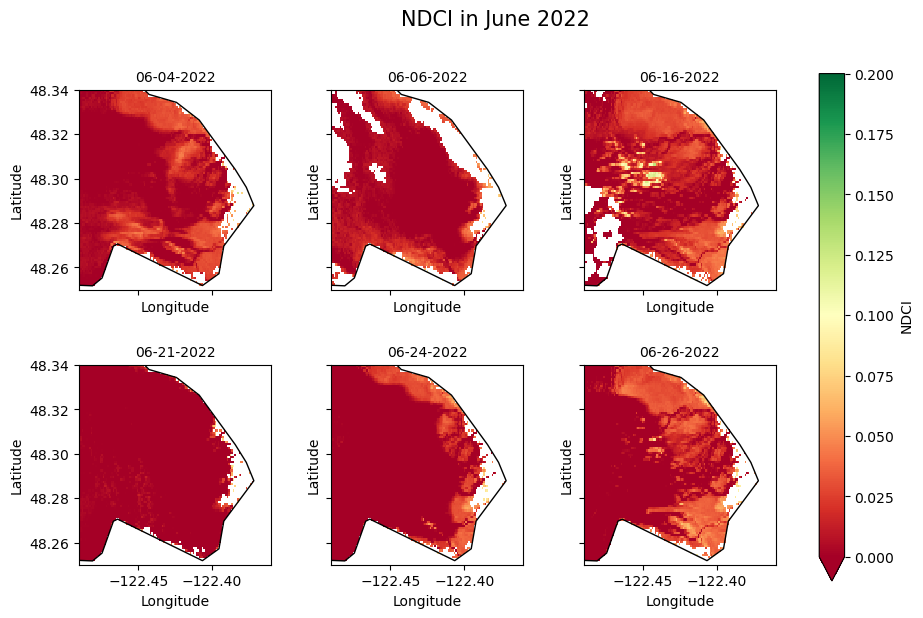

In [14]:
# now use s2_ds_water because we just want to track water not view the whole image

ndci_da = (s2_ds_water["B05"] - s2_ds_water["B04"]) / (s2_ds_water["B05"] + s2_ds_water["B04"])
water_only = s2_ds_water["SCL"] == 6
ndci_masked_da = ndci_da.where(water_only).sel(time=clean_times).compute()
ndci = ndci_masked_da.plot.imshow(col='time', col_wrap=3, robust=True, cmap='RdYlGn', vmin=0, vmax=0.20, cbar_kwargs={"label": "NDCI"})

for ax, t in zip(ndci.axes.flat, ndci_masked_da.time.values):
    ax.set_title(pd.Timestamp(t).strftime("%m-%d-%Y"), fontsize=10)
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")
    ax.set_xlim(zoom_bbox[0] + 0.01, zoom_bbox[2] - 0.01)
    ax.set_ylim(zoom_bbox[1] + 0.01, zoom_bbox[3] - 0.01)
    wa_gdf_clipped.boundary.plot(ax=ax, color='black', linewidth=1)

plt.suptitle("NDCI in June 2022", y=1.05, fontsize=15);

**Step 8: calculate the mean for each image**

In [12]:
ndci_median = ndci_masked_da.median(dim=["latitude", "longitude"])
print(ndci_median.values)

[ 0.0036242   0.00317245  0.01119569 -0.00817236 -0.01286031 -0.00776836]


Great, now this works for one month. Let's streamline this process and examine its effectiveness over time scales in the NDCI_processing.ipynb notebook.